In [2]:
import json
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

Load the JSON and create a master DataFrame of STIX objects

In [27]:
enterprise_file = "../enterprise-attack/enterprise-attack.json"
mobile_file = "../mobile-attack/mobile-attack.json"
ics_file = "../ics-attack/ics-attack.json"

with open(ics_file, "r", encoding="utf-8") as f:
    stix = json.load(f)

objects = stix.get("objects", [])
# Master dataframe (keeps the raw dict for reference)
master_df = pd.DataFrame([{
    "id": o.get("id"),
    "type": o.get("type"),
    "name": o.get("name"),
    "description": o.get("description"),
    "created": o.get("created"),
    "modified": o.get("modified"),
    "raw": o
} for o in objects])

master_df.head()


,id,type,name,description,created,modified,raw
0,x-mitre-collection--90c00720-636b-4485-b342-87...,x-mitre-collection,ICS ATT&CK,The ATT&CK for Industrial Control Systems (ICS...,2020-10-27T14:49:39.188Z,2025-10-28T14:00:00.188Z,"{'type': 'x-mitre-collection', 'id': 'x-mitre-..."
1,x-mitre-matrix--575f48f4-8897-4468-897b-48bb36...,x-mitre-matrix,ATT&CK for ICS,The full ATT&CK for ICS Matrix includes techni...,2018-10-17T00:14:20.652Z,2025-04-25T14:39:11.147Z,"{'type': 'x-mitre-matrix', 'spec_version': '2...."
2,course-of-action--059ba11e-e3dc-49aa-84ca-8819...,course-of-action,Application Isolation and Sandboxing,Restrict the execution of code to a virtual en...,2019-06-11T17:06:56.230Z,2025-04-16T21:26:25.920Z,"{'type': 'course-of-action', 'spec_version': '..."
3,course-of-action--11f242bc-3121-438c-84b2-5cbd...,course-of-action,Filter Network Traffic,Use network appliances to filter ingress or eg...,2019-06-11T16:33:55.337Z,2025-04-16T21:26:26.074Z,"{'type': 'course-of-action', 'spec_version': '..."
4,course-of-action--143b4398-3222-480a-b6a4-e131...,course-of-action,Restrict Web-Based Content,"Restrict use of certain websites, block downlo...",2019-06-06T20:52:59.206Z,2025-04-16T21:26:26.226Z,"{'type': 'course-of-action', 'spec_version': '..."


Extract techniques (ATT&CK `attack-pattern` objects)

In [28]:
tech_objs = [o for o in objects if o.get("type") == "attack-pattern"]

def technique_row(o):
    # external id e.g. T1003 usually in external_references where source_name == 'mitre-attack'
    ext_refs = o.get("external_references", [])
    mitre_ref = next((r for r in ext_refs if r.get("source_name") == "mitre-attack"), {})
    external_id = mitre_ref.get("external_id")
    # kill_chain_phases may contain tactic phase names
    kcp = o.get("kill_chain_phases") or o.get("kill_chain_phases", []) or []
    phases = [p.get("phase_name") for p in kcp if isinstance(p, dict) and p.get("phase_name")]
    platforms = o.get("x_mitre_platforms") or o.get("x-mitre-platforms") or []
    data_sources = o.get("x_mitre_data_sources") or []
    return {
        "id": o.get("id"),
        "tech_name": o.get("name"),
        "external_id": external_id,
        "description": o.get("description"),
        "platforms": platforms,
        "kill_chain_phases": phases,
        "raw": o
    }

tech_df = pd.DataFrame([technique_row(o) for o in tech_objs])
tech_df.head()


,id,tech_name,external_id,description,platforms,kill_chain_phases,raw
0,attack-pattern--008b8f56-6107-48be-aa9f-746f92...,Block Command Message,T0803,Adversaries may block a command message from r...,[None],[inhibit-response-function],"{'type': 'attack-pattern', 'spec_version': '2...."
1,attack-pattern--063b5b92-5361-481a-9c3f-95492e...,Service Stop,T0881,Adversaries may stop or disable services on a ...,[None],[inhibit-response-function],"{'type': 'attack-pattern', 'spec_version': '2...."
2,attack-pattern--097924ce-a9a9-4039-8591-e0deed...,Modify Parameter,T0836,Adversaries may modify parameters used to inst...,[None],[impair-process-control],"{'type': 'attack-pattern', 'spec_version': '2...."
3,attack-pattern--09a61657-46e1-439e-b3ed-3e4556...,Modify Controller Tasking,T0821,Adversaries may modify the tasking of a contro...,[None],[execution],"{'type': 'attack-pattern', 'spec_version': '2...."
4,attack-pattern--0fe075d5-beac-4d02-b93e-0f8749...,Wireless Sniffing,T0887,Adversaries may seek to capture radio frequenc...,[None],"[discovery, collection]","{'type': 'attack-pattern', 'spec_version': '2...."


Extract tactics (from kill_chain_phases) — canonicalize into a DataFrame

In [29]:
# Many ATT&CK bundles don't provide tactic objects as separate 'x-mitre-tactic' entries,
# but techniques include kill_chain_phases referencing 'mitre-attack' phase_name (tactic).
# We'll get the unique list of tactics from the techniques kill_chain_phases:

tactics = sorted({phase for phases in tech_df["kill_chain_phases"].tolist() for phase in phases if phase})
tactics_df = pd.DataFrame({"tactic": tactics})
tactics_df


,tactic
0,collection
1,command-and-control
2,discovery
3,evasion
4,execution
5,impact
6,impair-process-control
7,inhibit-response-function
8,initial-access
9,lateral-movement


Relationships DataFrame (useful for group->technique and other links)

In [30]:
rel_objs = [o for o in objects if o.get("type") == "relationship"]

rel_df = pd.DataFrame([{
    "id": o.get("id"),
    "relationship_type": o.get("relationship_type"),
    "source_ref": o.get("source_ref"),
    "target_ref": o.get("target_ref"),
    "description": o.get("description"),
    "raw": o
} for o in rel_objs])

rel_df.head()


,id,relationship_type,source_ref,target_ref,description,raw
0,relationship--007a2c53-fc5c-4750-aff0-defb282e...,targets,attack-pattern--53a26eee-1080-4d17-9762-2027d5...,x-mitre-asset--973bc51e-c41e-4cec-ac03-9389c71...,,"{'type': 'relationship', 'spec_version': '2.1'..."
1,relationship--00b9e63b-57a7-408e-83d6-fc035350...,uses,campaign--46421788-b6e1-4256-b351-f8beffd1afba,attack-pattern--8d2f3bab-507c-4424-b58b-edc977...,During the [2015 Ukraine Electric Power Attack...,"{'type': 'relationship', 'spec_version': '2.1'..."
2,relationship--00e6c22b-9275-4039-b6d4-2ac06803...,mitigates,course-of-action--aadac250-bcdc-44e3-a4ae-f52b...,attack-pattern--25dfc8ad-bd73-4dfd-84a9-3c3d38...,Use host-based allowlists to prevent devices f...,"{'type': 'relationship', 'spec_version': '2.1'..."
3,relationship--011f1d16-c9f1-48ac-94f1-165466c1...,targets,attack-pattern--25dfc8ad-bd73-4dfd-84a9-3c3d38...,x-mitre-asset--f1315d02-9118-4e3b-8cdf-4c2d3f7...,,"{'type': 'relationship', 'spec_version': '2.1'..."
4,relationship--012fd76f-1a10-4e48-9306-10ffae3f...,targets,attack-pattern--ead7bd34-186e-4c79-9a4d-b65bcc...,x-mitre-asset--973bc51e-c41e-4cec-ac03-9389c71...,,"{'type': 'relationship', 'spec_version': '2.1'..."


Map techniques to tactics (exploded rows, easy to group)

In [31]:
# explode kill_chain_phases into row-per-technique-per-tactic
tech_exploded = tech_df.explode("kill_chain_phases").rename(columns={"kill_chain_phases":"tactic"})
tech_exploded = tech_exploded[["id","external_id","tech_name","tactic","platforms"]]
tech_exploded.head()

,id,external_id,tech_name,tactic,platforms
0,attack-pattern--008b8f56-6107-48be-aa9f-746f92...,T0803,Block Command Message,inhibit-response-function,[None]
1,attack-pattern--063b5b92-5361-481a-9c3f-95492e...,T0881,Service Stop,inhibit-response-function,[None]
2,attack-pattern--097924ce-a9a9-4039-8591-e0deed...,T0836,Modify Parameter,impair-process-control,[None]
3,attack-pattern--09a61657-46e1-439e-b3ed-3e4556...,T0821,Modify Controller Tasking,execution,[None]
4,attack-pattern--0fe075d5-beac-4d02-b93e-0f8749...,T0887,Wireless Sniffing,discovery,[None]


## Analyses and Plots

Count techniques per tactic

tactic
inhibit-response-function    15
collection                   14
initial-access               14
impact                       12
execution                    12
discovery                     9
lateral-movement              8
evasion                       7
impair-process-control        7
persistence                   6
command-and-control           3
privilege-escalation          2
Name: id, dtype: int64


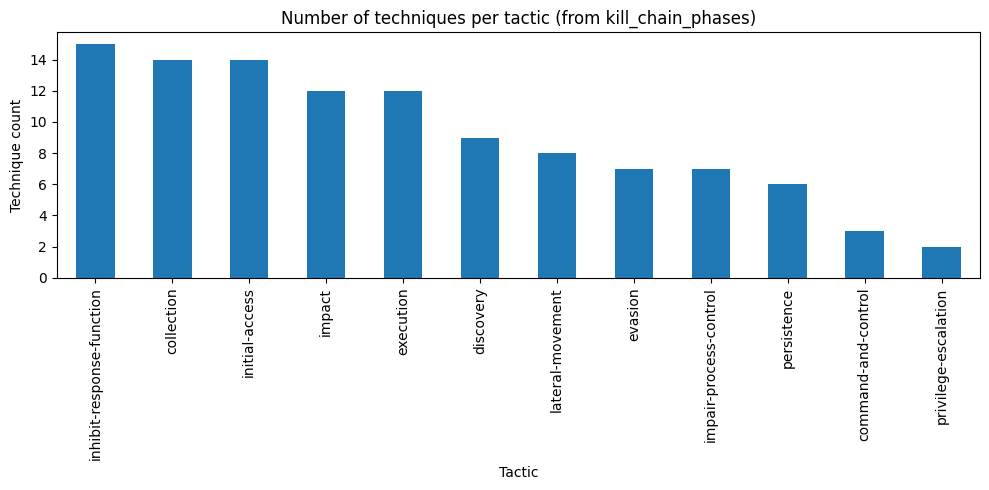

In [32]:
counts = tech_exploded.groupby("tactic")["id"].nunique().sort_values(ascending=False)
print(counts)

# simple bar plot
counts.plot(kind="bar", figsize=(10,5))
plt.title("Number of techniques per tactic (from kill_chain_phases)")
plt.ylabel("Technique count")
plt.xlabel("Tactic")
plt.tight_layout()
plt.show()


Count techniques mentioned by intrusion-sets / groups (via relationships)

In [33]:
# typical ATT&CK IDs: intrusion-set objects have type 'intrusion-set'
# relationships often link intrusion-set -> attack-pattern (technique)
# we can find those refs and join back to technique external_id

# 1) get list of intrusion-set objects and a mapping id->name
intrusion_objs = [o for o in objects if o.get("type") == "intrusion-set"]
intrusion_map = {o["id"]: o.get("name") for o in intrusion_objs}

# 2) filter relationships where target_ref is an attack-pattern id
# Note: target_ref contains full STIX id; match to tech_df.id
rel_is_to_tech = rel_df[rel_df["target_ref"].isin(tech_df["id"])]
# attach intrusion-set name if source_ref is an intrusion-set
rel_is_to_tech["intrusion_set_name"] = rel_is_to_tech["source_ref"].map(intrusion_map)
rel_is_to_tech = rel_is_to_tech.dropna(subset=["intrusion_set_name"])
rel_is_to_tech = rel_is_to_tech.merge(tech_df[["id","external_id","tech_name"]], left_on="target_ref", right_on="id", how="left")
rel_is_to_tech.head()

# Count by intrusion-set
counts_by_is = rel_is_to_tech.groupby("intrusion_set_name")["external_id"].nunique().sort_values(ascending=False)
print(counts_by_is.head(20))


intrusion_set_name
OilRig           5
ALLANITE         4
APT33            3
Sandworm Team    3
Dragonfly        2
TEMP.Veles       2
Lazarus Group    1
Name: external_id, dtype: int64


/tmp/ipykernel_14152/2689066225.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rel_is_to_tech["intrusion_set_name"] = rel_is_to_tech["source_ref"].map(intrusion_map)


Build a bipartite graph (intrusion-set <-> technique)


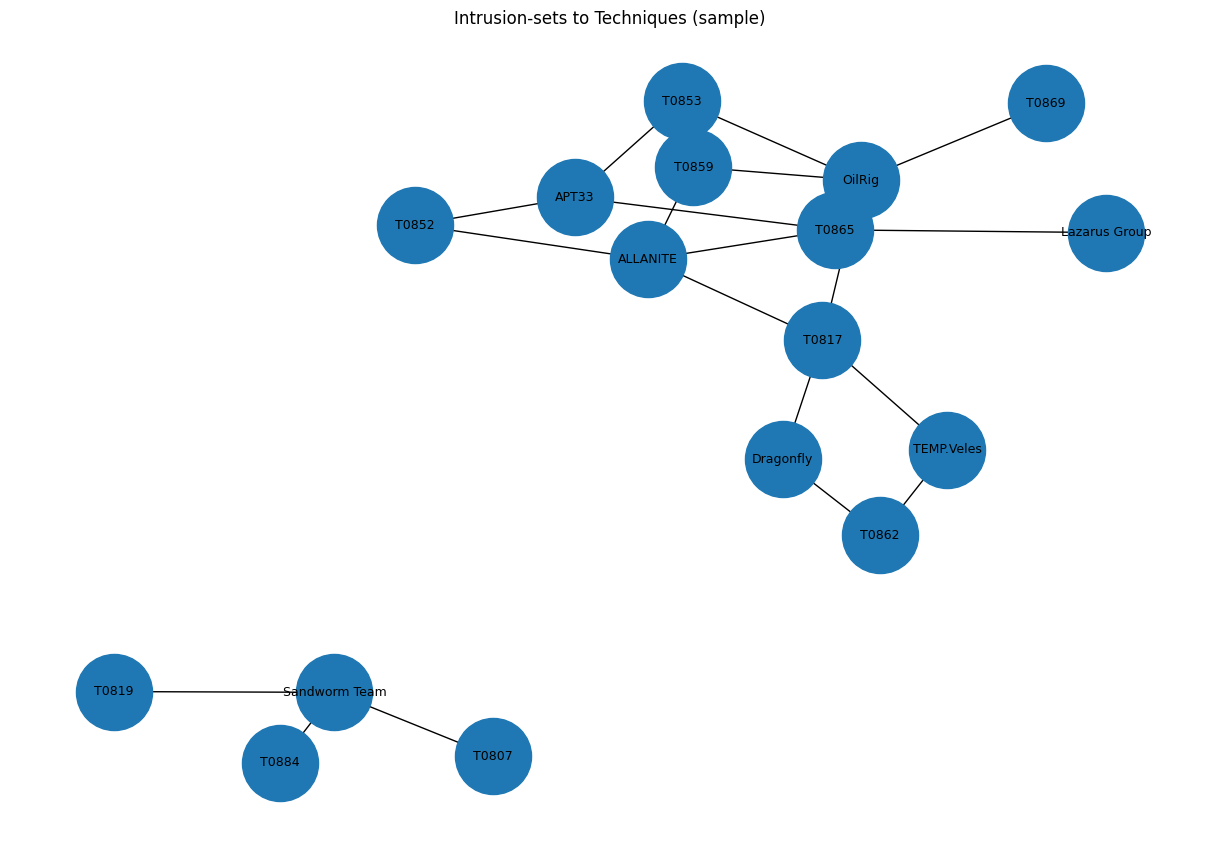

In [34]:
# Build NetworkX bipartite graph
G = nx.Graph()
# add intrusion-set nodes
for is_id, is_name in intrusion_map.items():
    G.add_node(is_name, bipartite="intrusion-set")
# add technique nodes and edges
for _, row in rel_is_to_tech.iterrows():
    is_name = row["intrusion_set_name"]
    tech = f"{row['external_id'] or row['tech_name']}"
    G.add_node(tech, bipartite="technique")
    G.add_edge(is_name, tech)

# Draw a small subgraph (limit to top 10 intrusion-sets by degree to keep it readable)
top_is = counts_by_is.head(8).index.tolist()
sub_nodes = set(top_is)
for n in top_is:
    sub_nodes |= set(G.neighbors(n))
subG = G.subgraph(sub_nodes)

plt.figure(figsize=(12,8))
pos = nx.spring_layout(subG, k=0.5)
nx.draw(subG, pos, with_labels=True, node_size=3000, font_size=9)
plt.title("Intrusion-sets to Techniques (sample)")
plt.show()


In [35]:
# Filter relationships where source is intrusion-set and target is attack-pattern (technique)
rel_uses = rel_df[
    (rel_df["relationship_type"] == "uses") &
    (rel_df["source_ref"].str.startswith("intrusion-set")) &
    (rel_df["target_ref"].str.startswith("attack-pattern"))
].copy()

# Map intrusion-set names
rel_uses["intrusion_set_name"] = rel_uses["source_ref"].map(intrusion_map)

# Join in technique info (external_id and name)
rel_uses = rel_uses.merge(
    tech_df[["id", "external_id", "tech_name"]],
    left_on="target_ref", right_on="id", how="left"
)

rel_uses.head()


,id_x,relationship_type,source_ref,target_ref,description,raw,intrusion_set_name,id_y,external_id,tech_name
0,relationship--042243fd-bfe0-4961-96de-a36232d3...,uses,intrusion-set--1c63d4ec-0a75-4daa-b1df-0d11af3...,attack-pattern--7830cfcf-b268-4ac0-a69e-73c6af...,[Dragonfly](https://attack.mitre.org/groups/G0...,"{'type': 'relationship', 'spec_version': '2.1'...",Dragonfly,attack-pattern--7830cfcf-b268-4ac0-a69e-73c6af...,T0817,Drive-by Compromise
1,relationship--0beb0088-3bea-4612-b2d9-ff9988f8...,uses,intrusion-set--fbd29c89-18ba-4c2d-b792-51c0ade...,attack-pattern--c5e3cdbc-0387-4be9-8f83-ff5c08...,[APT33](https://attack.mitre.org/groups/G0064)...,"{'type': 'relationship', 'spec_version': '2.1'...",APT33,attack-pattern--c5e3cdbc-0387-4be9-8f83-ff5c08...,T0852,Screen Capture
2,relationship--0eb112f6-c1cb-4843-93f5-f668aa0e...,uses,intrusion-set--190242d7-73fc-4738-af68-20162f7...,attack-pattern--cd2c76a4-5e23-4ca5-9c40-d5e060...,[ALLANITE](https://attack.mitre.org/groups/G10...,"{'type': 'relationship', 'spec_version': '2.1'...",ALLANITE,attack-pattern--cd2c76a4-5e23-4ca5-9c40-d5e060...,T0859,Valid Accounts
3,relationship--0f18b876-b698-4f70-aa98-50e8b5a7...,uses,intrusion-set--fbd29c89-18ba-4c2d-b792-51c0ade...,attack-pattern--648f995e-9c3a-41e4-aeee-98bb41...,[APT33](https://attack.mitre.org/groups/G0064)...,"{'type': 'relationship', 'spec_version': '2.1'...",APT33,attack-pattern--648f995e-9c3a-41e4-aeee-98bb41...,T0865,Spearphishing Attachment
4,relationship--26d68f5d-6ee5-4d98-b175-943366cc...,uses,intrusion-set--381fcf73-60f6-4ab2-9991-6af3cbc...,attack-pattern--24a9253e-8948-4c98-b751-8e2aee...,[Sandworm Team](https://attack.mitre.org/group...,"{'type': 'relationship', 'spec_version': '2.1'...",Sandworm Team,attack-pattern--24a9253e-8948-4c98-b751-8e2aee...,T0807,Command-Line Interface


In [36]:
# Count total number of unique intrusion sets using each technique
tech_use_counts = (
    rel_uses.groupby(["external_id", "tech_name"])["intrusion_set_name"]
    .nunique()  # number of distinct intrusion sets per technique
    .reset_index(name="use_count")
    .sort_values("use_count", ascending=False)
)

tech_use_counts.head(10)


,external_id,tech_name,use_count
1,T0817,Drive-by Compromise,4
7,T0865,Spearphishing Attachment,4
6,T0862,Supply Chain Compromise,2
3,T0852,Screen Capture,2
5,T0859,Valid Accounts,2
4,T0853,Scripting,2
0,T0807,Command-Line Interface,1
2,T0819,Exploit Public-Facing Application,1
8,T0869,Standard Application Layer Protocol,1
9,T0884,Connection Proxy,1


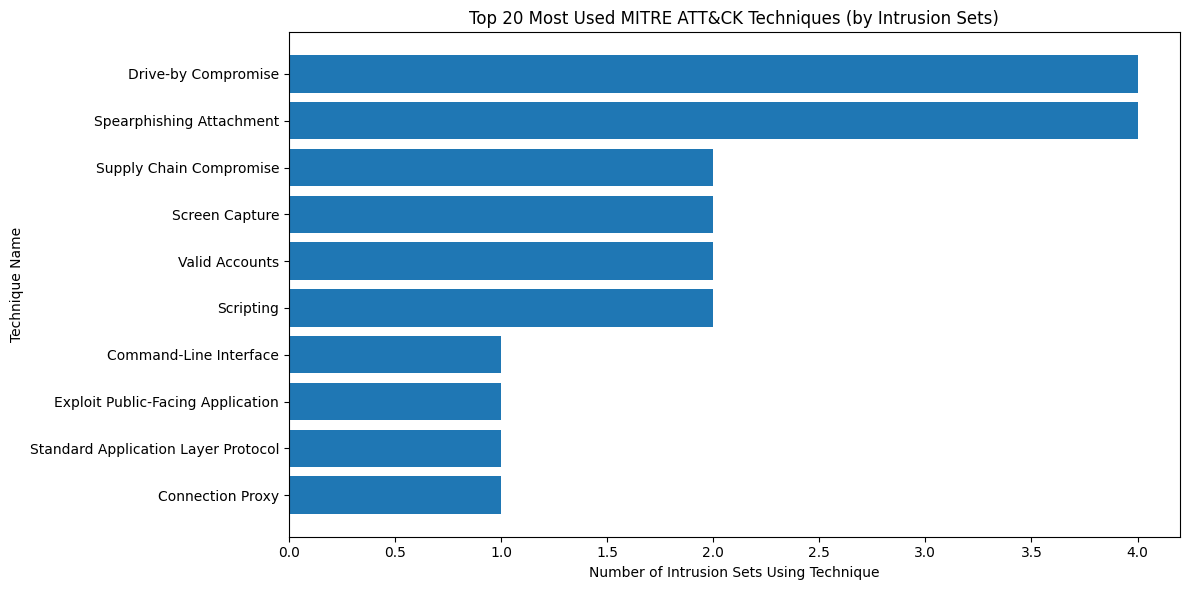

In [37]:
# Sort by use_count descending and keep top 20 techniques
top_techs = tech_use_counts.sort_values("use_count", ascending=False).head(20)

plt.figure(figsize=(12, 6))
plt.barh(
    top_techs["tech_name"][::-1],   # ← show names on Y-axis
    top_techs["use_count"][::-1],   # ← counts on X-axis
)

plt.title("Top 20 Most Used MITRE ATT&CK Techniques (by Intrusion Sets)")
plt.xlabel("Number of Intrusion Sets Using Technique")
plt.ylabel("Technique Name")
plt.tight_layout()
plt.show()


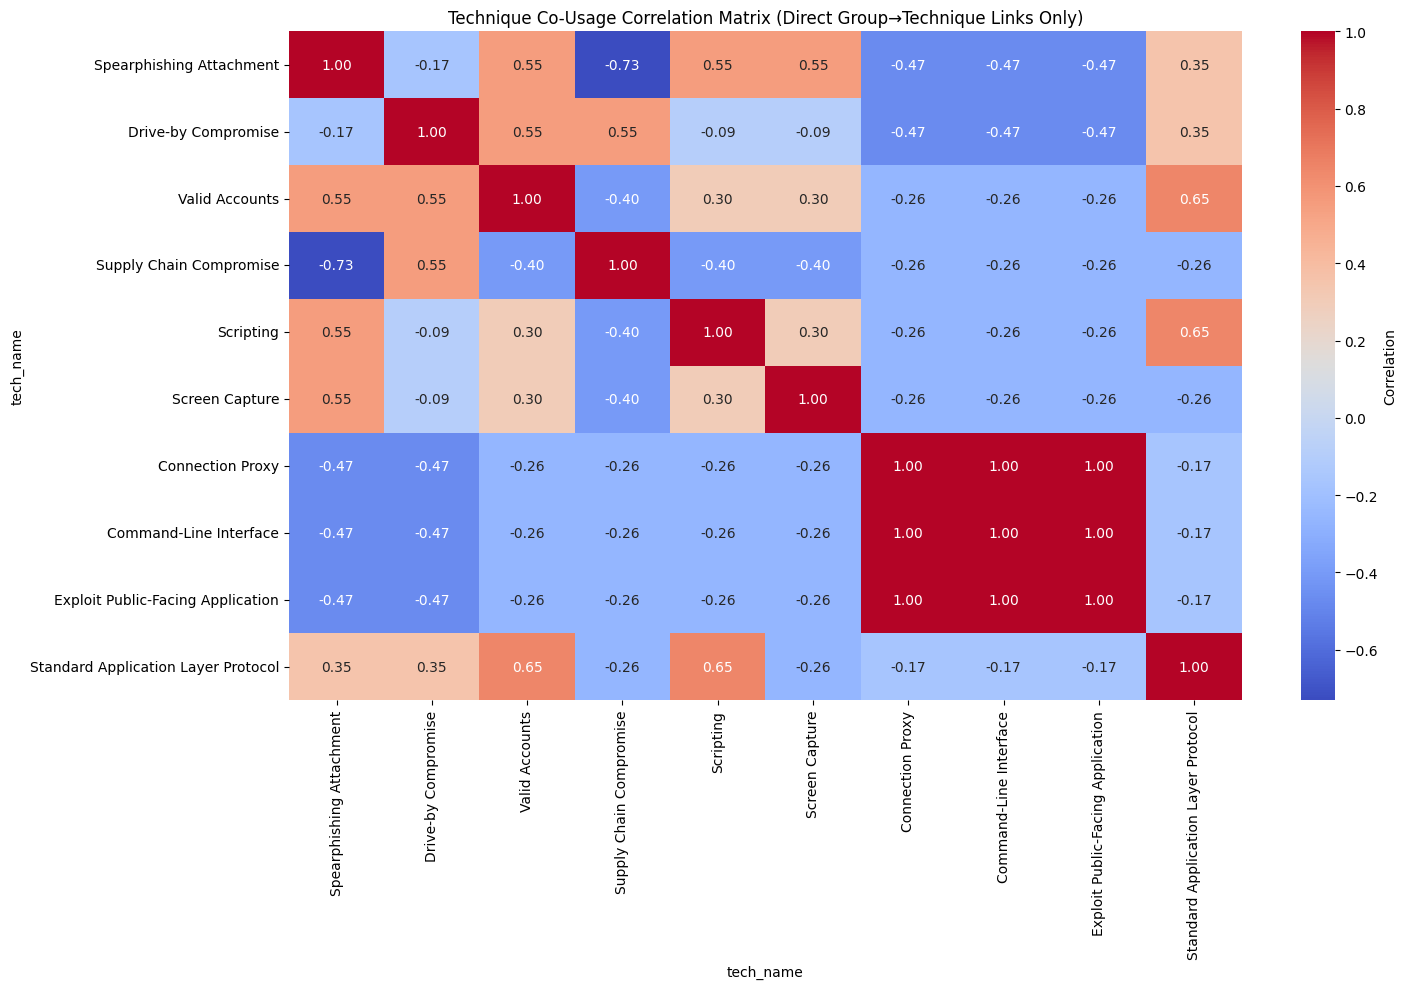

In [38]:
# Use ONLY direct group→technique relationships (already created earlier as rel_uses)
direct_df = rel_uses[["intrusion_set_name", "external_id", "tech_name"]].dropna()

# 1️⃣ Pivot into a binary matrix:
# Rows = intrusion sets, Columns = techniques, Values = 1 if group uses technique
usage_matrix_direct = (
    direct_df
    .assign(value=1)
    .pivot_table(
        index="intrusion_set_name",
        columns="tech_name",
        values="value",
        fill_value=0
    )
)

# 2️⃣ Compute correlation between techniques
corr_matrix_direct = usage_matrix_direct.corr()

# 3️⃣ (Optional) Focus on the top N most-used techniques to keep visualization readable
top_techs_direct = (
    direct_df.groupby("tech_name")["intrusion_set_name"]
    .nunique()
    .sort_values(ascending=False)
    .head(25)
    .index
)

corr_subset_direct = corr_matrix_direct.loc[top_techs_direct, top_techs_direct]

# 4️⃣ Visualize as a heatmap
plt.figure(figsize=(15,10))
sns.heatmap(
    corr_subset_direct,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"label": "Correlation"},
)
plt.title("Technique Co-Usage Correlation Matrix (Direct Group→Technique Links Only)")
plt.tight_layout()
plt.show()
